In [1]:
import os
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
def simple_center_image(image, target_size=45):
    h, w = image.shape

    squared = np.zeros((target_size, target_size), dtype=np.uint8)

    y_offset = (target_size - h) // 2
    x_offset = (target_size - w) // 2

    squared[y_offset:y_offset + h, x_offset:x_offset + w] = image
    return squared

In [2]:
def load_training_data_simple(data_path, symbols, train_size=0.8):
    X_train, y_train = [], []

    for symbol in symbols:
        symbol_path = os.path.join(data_path, symbol)
        if not os.path.exists(symbol_path):
            continue

        images = [f for f in os.listdir(symbol_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        images.sort()

        split_idx = int(len(images) * train_size)
        train_images = images[:split_idx]

        print(f"Загрузка символа '{symbol}': {len(train_images)} изображений")

        for img_name in train_images:
            img_path = os.path.join(symbol_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.bitwise_not(img)
                img_resized = simple_center_image(img)
                X_train.append(img_resized.flatten())
                y_train.append(symbol)

    return np.array(X_train), np.array(y_train)

In [3]:
class SimpleSequenceGenerator:
    def __init__(self, data_path):
        self.data_path = data_path
        self.symbols_data = {}
        self.available_symbols = []
        self.load_symbols()

    def load_symbols(self):
        folders = [f for f in os.listdir(self.data_path)
                   if os.path.isdir(os.path.join(self.data_path, f))]

        print("Загружаемые символы:", sorted(folders))

        for folder in folders:
            folder_path = os.path.join(self.data_path, folder)
            images = []

            for filename in os.listdir(folder_path):
                if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                    file_path = os.path.join(folder_path, filename)
                    images.append(file_path)

            if images:
                self.symbols_data[folder] = images
                self.available_symbols.append(folder)
                print(f"Символ '{folder}': {len(images)} изображений")

    def generate_sequence_image(self, length=6):
        if not self.available_symbols:
            return None

        sequence_images = []
        labels = []

        for i in range(length):
            symbol = random.choice(self.available_symbols)
            image_path = random.choice(self.symbols_data[symbol])
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

            if image is not None:
                sequence_images.append(image)
                labels.append(symbol)

        spacing = 20
        total_width = sum(img.shape[1] for img in sequence_images) + spacing * (len(sequence_images) - 1)
        max_height = max(img.shape[0] for img in sequence_images)

        sequence_img = np.ones((max_height, total_width), dtype=np.uint8) * 255

        x_offset = 0
        for img in sequence_images:
            h, w = img.shape[:2]
            y_offset = (max_height - h) // 2
            sequence_img[y_offset:y_offset + h, x_offset:x_offset + w] = img
            x_offset += w + spacing

        return {
            'image': sequence_img,
            'labels': labels,
            'text': ''.join(labels)
        }

In [4]:
class SimpleSequenceSegmenter:
    def extract_characters(self, sequence_image, original_labels):
        print(f"Исходная последовательность: {' '.join(original_labels)}")

        img_gray = sequence_image.copy()

        kernel = np.ones((3, 3), np.uint8)
        img_gray = cv2.erode(img_gray, kernel, iterations=1)
        img_gray = cv2.bitwise_not(img_gray)

        _, thresh = cv2.threshold(img_gray, 127, 255, 0)
        thresh = np.uint8(thresh)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        contours_sorted = sorted(contours, key=lambda cnt: cv2.boundingRect(cnt)[0])
        crops = []

        img_with_boxes = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)

        for i, cnt in enumerate(contours_sorted):
            x, y, w, h = cv2.boundingRect(cnt)
            while w > 45:
                w -= 1
            if w * h > 50:
                cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (0, 0, 255), 1)
                crops.append([x, y, w, h])

        plt.figure(figsize=(12, 5))
        plt.imshow(img_with_boxes)
        plt.title('Найденные контуры символов')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

        character_data = []
        for i, (x, y, w, h) in enumerate(crops):
            img_crop = sequence_image[y:y + h, x:x + w]

            img_processed = cv2.bitwise_not(img_crop)
            img_resized = simple_center_image(img_processed)

            true_label = original_labels[i] if i < len(original_labels) else "?"

            character_data.append((true_label, img_resized))
            print(f"Извлечен символ {i + 1}: '{true_label}'")

        return character_data

In [5]:
def evaluate_models_simple(models, X_test, y_test):
    print("\nОЦЕНКА МОДЕЛЕЙ НА ТЕСТОВЫХ ДАННЫХ:")
    print("=" * 50)

    results = {}
    for model_name, model in models.items():
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        results[model_name] = accuracy
        print(f"{model_name}: Точность {accuracy:.3f}")

    return results

СИСТЕМА РАСПОЗНАВАНИЯ РУКОПИСНЫХ СИМВОЛОВ
Доступные символы: ['(', ')', '+', ',', '-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'X', 'h', 't', 'times', 'w', 'y']

ГЕНЕРАЦИЯ ТЕСТОВОЙ ПОСЛЕДОВАТЕЛЬНОСТИ

ИНИЦИАЛИЗАЦИЯ ГЕНЕРАТОРА ПОСЛЕДОВАТЕЛЬНОСТЕЙ...
Загружаемые символы: ['(', ')', '+', ',', '-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'X', 'h', 't', 'times', 'w', 'y']
Символ 'times': 3251 изображений
Символ '9': 628 изображений
Символ '0': 6914 изображений
Символ '7': 2909 изображений
Символ '+': 25112 изображений
Символ ',': 1906 изображений
Символ '6': 3118 изображений
Символ '1': 26520 изображений
Символ '8': 3068 изображений
Символ 't': 3274 изображений
Символ '-': 33997 изображений
Символ 'h': 1464 изображений
Символ '(': 14294 изображений
Символ '4': 7396 изображений
Символ 'X': 26594 изображений
Символ '3': 10909 изображений
Символ ')': 14355 изображений
Символ '2': 26141 изображений
Символ 'y': 9340 изображений
Символ '5': 3545 изображений
Символ 'w': 556 изо

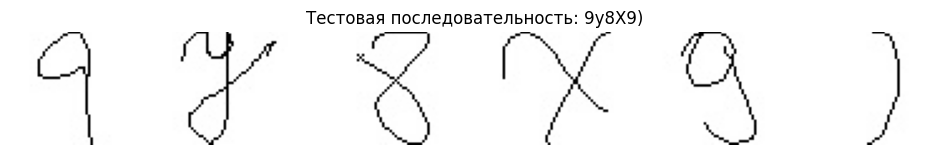

Исходная последовательность: 9 y 8 X 9 )


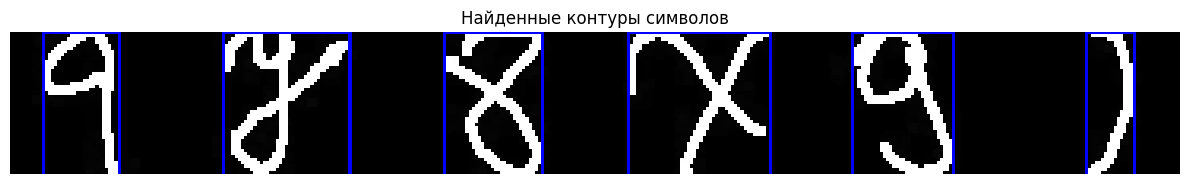

Извлечен символ 1: '9'
Извлечен символ 2: 'y'
Извлечен символ 3: '8'
Извлечен символ 4: 'X'
Извлечен символ 5: '9'
Извлечен символ 6: ')'
Извлечено 6 символов из последовательности

Символ 1: '9'


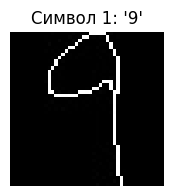


Символ 2: 'y'


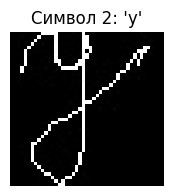


Символ 3: '8'


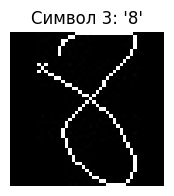


Символ 4: 'X'


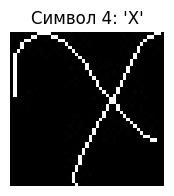


Символ 5: '9'


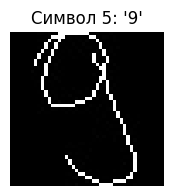


Символ 6: ')'


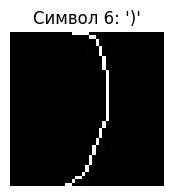


ЗАГРУЗКА ДАННЫХ И ОБУЧЕНИЕ МОДЕЛЕЙ

ЗАГРУЗКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ...
Загрузка символа '(': 11435 изображений
Загрузка символа ')': 11484 изображений
Загрузка символа '+': 20089 изображений
Загрузка символа ',': 1524 изображений
Загрузка символа '-': 27197 изображений
Загрузка символа '0': 5531 изображений
Загрузка символа '1': 21216 изображений
Загрузка символа '2': 20912 изображений
Загрузка символа '3': 8727 изображений
Загрузка символа '4': 5916 изображений
Загрузка символа '5': 2836 изображений
Загрузка символа '6': 2494 изображений
Загрузка символа '7': 2327 изображений
Загрузка символа '8': 2454 изображений
Загрузка символа '9': 502 изображений
Загрузка символа 'X': 21275 изображений
Загрузка символа 'h': 1171 изображений
Загрузка символа 't': 2619 изображений
Загрузка символа 'times': 2600 изображений
Загрузка символа 'w': 444 изображений
Загрузка символа 'y': 7472 изображений
Загружено 180225 изображений для обучения
Обучающая выборка: 144180 изображений
Тестовая выборка: 36045

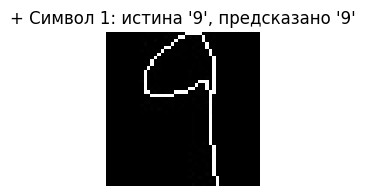

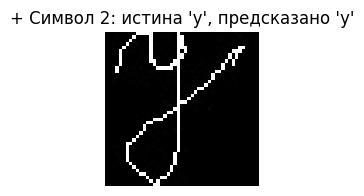

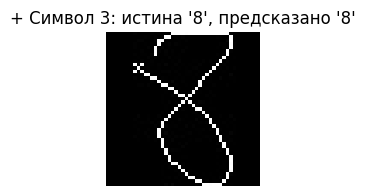

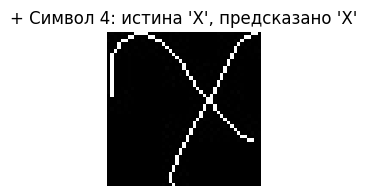

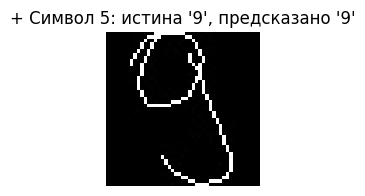

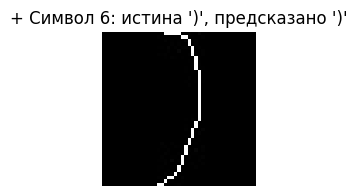

    Оригинал:  9y8X9)
    Предсказано: 9y8X9)
    Точность: 100.0% (6/6)

--- Модель knn3 ---


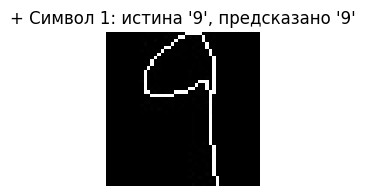

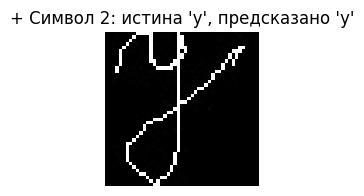

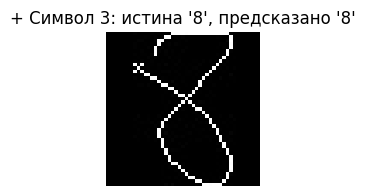

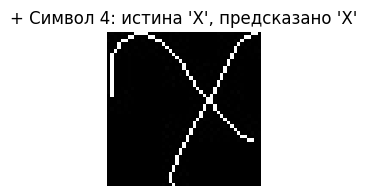

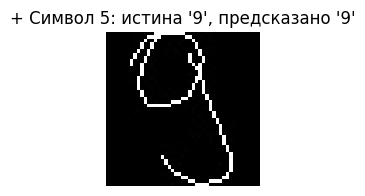

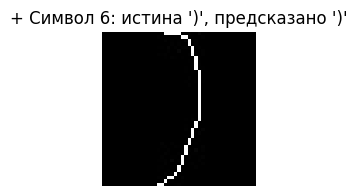

    Оригинал:  9y8X9)
    Предсказано: 9y8X9)
    Точность: 100.0% (6/6)

--- Модель knn5 ---


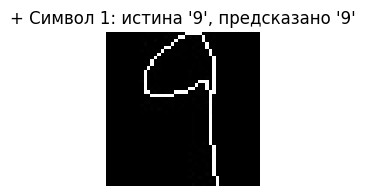

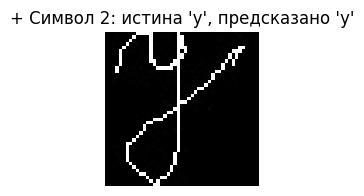

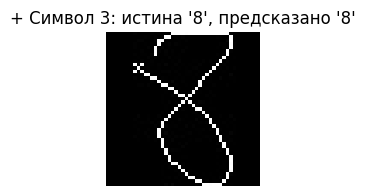

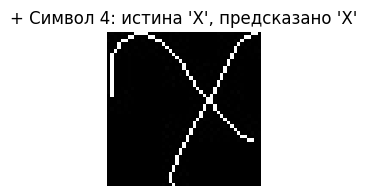

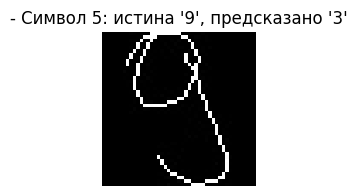

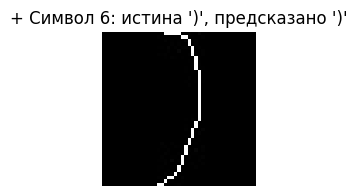

    Оригинал:  9y8X9)
    Предсказано: 9y8X3)
    Точность: 83.3% (5/6)

--- Модель knn7 ---


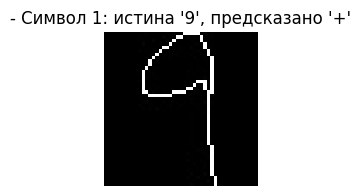

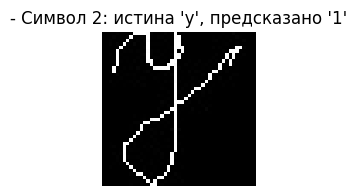

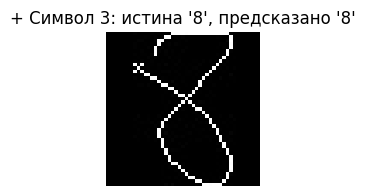

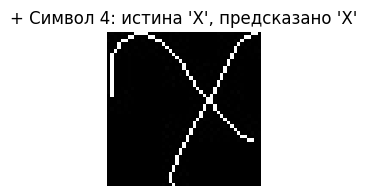

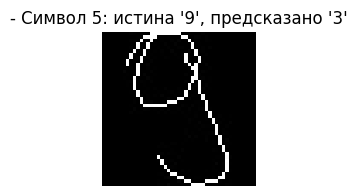

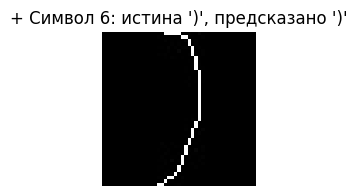

    Оригинал:  9y8X9)
    Предсказано: +18X3)
    Точность: 50.0% (3/6)

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ
knn1: 100.0% - '9y8X9)'
knn3: 100.0% - '9y8X9)'
knn5: 83.3% - '9y8X3)'
knn7: 50.0% - '+18X3)'
НЕСКОЛЬКО ЛУЧШИХ МОДЕЛЕЙ: knn1, knn3 с точностью 100.0%

РАБОТА ЗАВЕРШЕНА


In [6]:
def main():
    DATA_PATH = './data'

    print("=" * 60)
    print("СИСТЕМА РАСПОЗНАВАНИЯ РУКОПИСНЫХ СИМВОЛОВ")
    print("=" * 60)

    symbols = []
    if os.path.exists(DATA_PATH):
        symbols = [f for f in os.listdir(DATA_PATH)
                   if os.path.isdir(os.path.join(DATA_PATH, f))]
        symbols.sort()

    print("Доступные символы:", symbols)

    if not symbols:
        print("Нет символов для обучения!")
        return


    print("\n" + "=" * 60)
    print("ГЕНЕРАЦИЯ ТЕСТОВОЙ ПОСЛЕДОВАТЕЛЬНОСТИ")
    print("=" * 60)
    
    print("\nИНИЦИАЛИЗАЦИЯ ГЕНЕРАТОРА ПОСЛЕДОВАТЕЛЬНОСТЕЙ...")
    generator = SimpleSequenceGenerator(DATA_PATH)
    segmenter = SimpleSequenceSegmenter()

    sequence_data = generator.generate_sequence_image(length=6)
    
    if sequence_data:
        print(f"Сгенерирована последовательность: {sequence_data['text']}")
        
        plt.figure(figsize=(12, 5))
        plt.imshow(sequence_data['image'], cmap='gray')
        plt.title(f'Тестовая последовательность: {sequence_data["text"]}')
        plt.axis('off')
        plt.show()
        
        characters = segmenter.extract_characters(sequence_data['image'], sequence_data['labels'])
        
        if not characters:
            print("Не удалось извлечь символы из последовательности!")
            return
            
        print(f"Извлечено {len(characters)} символов из последовательности")
        
        for i, (true_label, char_img) in enumerate(characters):
            print(f"\nСимвол {i + 1}: '{true_label}'")
            plt.figure(figsize=(3, 2))
            plt.imshow(char_img, cmap='gray')
            plt.title(f"Символ {i + 1}: '{true_label}'")
            plt.axis('off')
            plt.show()

        print("\n" + "=" * 60)
        print("ЗАГРУЗКА ДАННЫХ И ОБУЧЕНИЕ МОДЕЛЕЙ")
        print("=" * 60)
        
        print("\nЗАГРУЗКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ...")
        X, y = load_training_data_simple(DATA_PATH, symbols, train_size=0.8)

        if len(X) == 0:
            print("Не удалось загрузить данные для обучения!")
            return

        print(f"Загружено {len(X)} изображений для обучения")

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        print(f"Обучающая выборка: {X_train.shape[0]} изображений")
        print(f"Тестовая выборка: {X_test.shape[0]} изображений")

        print("\nОБУЧЕНИЕ МОДЕЛЕЙ KNN:")
        models = {}
        k_values = [1, 3, 5, 7]

        for k in k_values:
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_train, y_train)
            models[f'knn{k}'] = knn
            print(f"KNN-{k} обучен")

        test_results = evaluate_models_simple(models, X_test, y_test)
        best_model_name = max(test_results, key=test_results.get)
        best_model = models[best_model_name]
        print(f"\nЛУЧШАЯ МОДЕЛЬ НА ТЕСТЕ: {best_model_name} с точностью {test_results[best_model_name]:.3f}")


        print("\n" + "=" * 60)
        print("ТЕСТИРОВАНИЕ НА СГЕНЕРИРОВАННОЙ ПОСЛЕДОВАТЕЛЬНОСТИ")
        print("=" * 60)
        
        print(f"Используется последовательность: {sequence_data['text']}")
        
        print("\n" + "=" * 60)
        print("СРАВНЕНИЕ ТОЧНОСТИ МОДЕЛЕЙ")
        print("=" * 60)

        results = {}

        for model_name, model in models.items():
            print(f"\n--- Модель {model_name} ---")

            predicted_labels = []
            correct_count = 0

            for i, (true_label, char_img) in enumerate(characters):
                predicted = model.predict([char_img.flatten()])[0]
                predicted_labels.append(predicted)

                is_correct = (predicted == true_label)
                status = "+" if is_correct else "-"

                if is_correct:
                    correct_count += 1
                plt.figure(figsize=(3, 2))
                plt.imshow(char_img, cmap='gray')
                plt.title(f"{status} Символ {i + 1}: истина '{true_label}', предсказано '{predicted}'")
                plt.axis('off')
                plt.show()

            predicted_text = ''.join(predicted_labels)
            original_text = sequence_data['text']

            total = len(sequence_data['labels'])
            accuracy = correct_count / total

            print(f"    Оригинал:  {original_text}")
            print(f"    Предсказано: {predicted_text}")
            print(f"    Точность: {accuracy:.1%} ({correct_count}/{total})")

            results[model_name] = {
                'accuracy': accuracy,
                'predicted': predicted_text,
                'correct': correct_count,
                'total': total
            }

        print("\n" + "=" * 60)
        print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ")
        print("=" * 60)

        sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)

        for model_name, result in sorted_results:
            print(f"{model_name}: {result['accuracy']:.1%} - '{result['predicted']}'")

        best_accuracy = sorted_results[0][1]['accuracy']
        best_models = [model for model, res in results.items() if res['accuracy'] == best_accuracy]

        if len(best_models) == 1:
            print(f"ЛУЧШАЯ МОДЕЛЬ: {best_models[0]} с точностью {best_accuracy:.1%}")
        else:
            print(f"НЕСКОЛЬКО ЛУЧШИХ МОДЕЛЕЙ: {', '.join(best_models)} с точностью {best_accuracy:.1%}")

    print("\n" + "=" * 60)
    print("РАБОТА ЗАВЕРШЕНА")
    print("=" * 60)


if __name__ == "__main__":
    main()